Code to check difference between interpolation methods

In [2]:
import numpy as np

import matplotlib.pyplot as plt


In [7]:
def trilinear_interpolate(F,x,y,z):
    # Find the integer grid points surrounding (x, y, z)
    i, j, k = int(x), int(y), int(z)
    tx, ty, tz = x - i, y - j, z - k  # Fractional parts

    # Wrap indices if necessary, assuming periodic boundary conditions
    i1, j1, k1 = (i + 1) % F.shape[0], (j + 1) % F.shape[1], (k + 1) % F.shape[2]
    
    # Get values at surrounding points
    c000 = F[i, j, k]
    c100 = F[i1, j, k]
    c010 = F[i, j1, k]
    c110 = F[i1, j1, k]
    c001 = F[i, j, k1]
    c101 = F[i1, j, k1]
    c011 = F[i, j1, k1]
    c111 = F[i1, j1, k1]

    # Perform trilinear interpolation
    c00 = c000 * (1 - tx) + c100 * tx
    c10 = c010 * (1 - tx) + c110 * tx
    c01 = c001 * (1 - tx) + c101 * tx
    c11 = c011 * (1 - tx) + c111 * tx

    c0 = c00 * (1 - ty) + c10 * ty
    c1 = c01 * (1 - ty) + c11 * ty

    return c0 * (1 - tz) + c1 * tz

def cubic_interpolate(p, t):
    """
    Performs cubic interpolation for one dimension.

    Parameters:
    p (list or array): Array of 4 control points along one dimension.
    t (float): Fractional distance along the dimension (0 <= t <= 1).

    Returns:
    float: Interpolated value.
    """
    return p[1] + 0.5 * t * (p[2] - p[0] +
             t * (2.0 * p[0] - 5.0 * p[1] + 4.0 * p[2] - p[3] +
             t * (3.0 * (p[1] - p[2]) + p[3] - p[0])))

def tricubic_interpolate(volume_fraction, Nx, x, y, z):
    """
    Performs tricubic interpolation on a given volume fraction.

    Parameters:
    volume_fraction (ndarray): The volume fraction data (3D array).
    Nx (list): The size of the volume in each dimension [Nx, Ny, Nz].
    x, y, z (float): The coordinates of the point to interpolate.

    Returns:
    float: The interpolated value at the given point.
    """
    Nx0, Nx1, Nx2 = Nx

    # Calculate integer indices surrounding the point (x, y, z)
    i = int(x)
    j = int(y)
    k = int(z)

    # Compute fractional distances within the grid cell
    tx = x - i
    ty = y - j
    tz = z - k

    # Helper function to wrap around boundaries (Periodic Boundary Conditions)
    def wrap(idx, max_size):
        return (idx + max_size) % max_size

    # Extract a 4x4x4 neighborhood of values
    values = np.zeros((4, 4, 4))
    for dz in range(4):
        for dy in range(4):
            for dx in range(4):
                x_idx = wrap(i + dx - 1, Nx0)
                y_idx = wrap(j + dy - 1, Nx1)
                z_idx = wrap(k + dz - 1, Nx2)
                values[dz, dy, dx] = volume_fraction[x_idx, y_idx, z_idx]

    # Perform cubic interpolation along the x-axis for each yz-plane
    temp = np.zeros((4, 4))
    for dz in range(4):
        for dy in range(4):
            temp[dz, dy] = cubic_interpolate(values[dz, dy, :], tx)

    # Perform cubic interpolation along the y-axis for each z-plane
    temp2 = np.zeros(4)
    for dz in range(4):
        temp2[dz] = cubic_interpolate(temp[dz, :], ty)

    # Perform cubic interpolation along the z-axis
    return cubic_interpolate(temp2, tz)

Trilinear Interpolation:
Mean Relative Error: 0.4324649226012497
Max Relative Error: 27.379178692971042

Tricubic Interpolation:
Mean Relative Error: 0.4345478233585284
Max Relative Error: 27.511965950890204


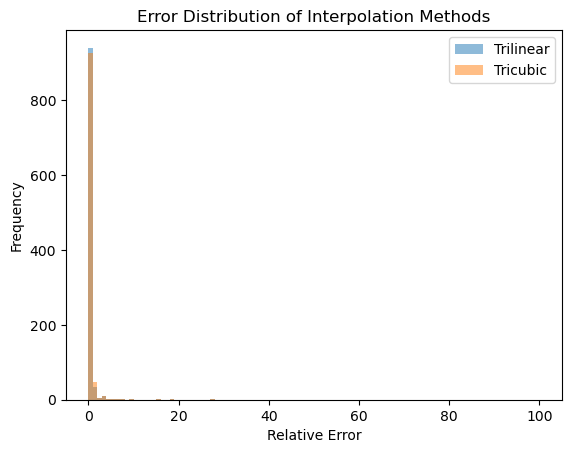

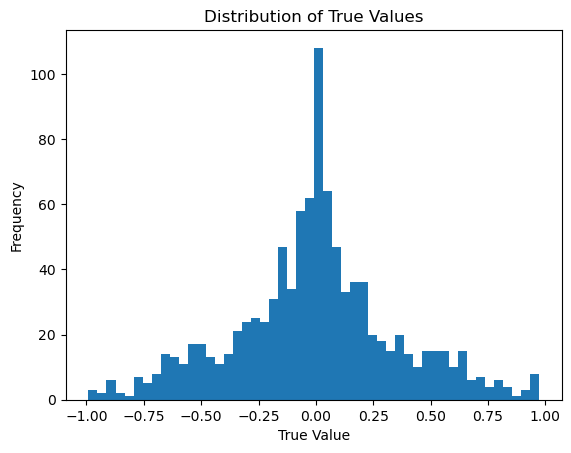

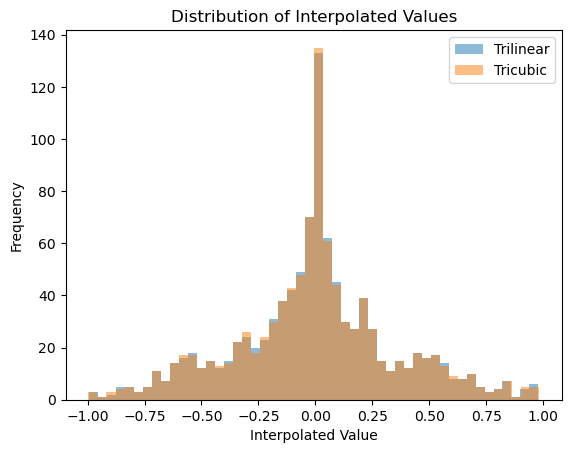

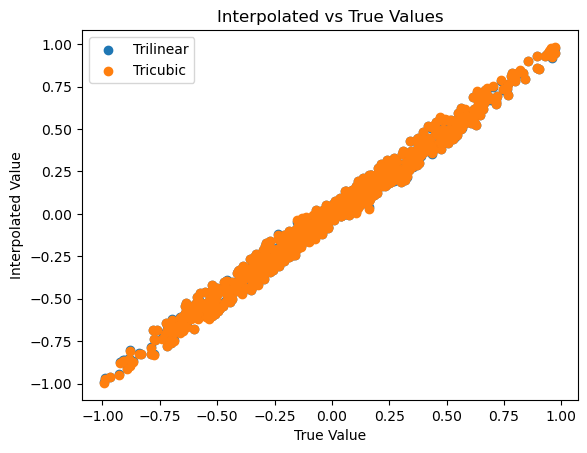

In [9]:
# Grid parameters
Nx, Ny, Nz = 50, 50, 50
grid_range = 2 * np.pi
x = np.linspace(0, grid_range, Nx)
y = np.linspace(0, grid_range, Ny)
z = np.linspace(0, grid_range, Nz)

# Known function on the grid
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
grid_data = np.sin(X) * np.cos(Y) * np.sin(Z)
dx, dy, dz = grid_range / Nx, grid_range / Ny, grid_range / Nz


num_points = 1000
random_points = np.random.rand(num_points, 3) * (2 * np.pi)  # Random points in grid
trilinear_values = []
tricubic_values = []
trilinear_errors = []
tricubic_errors = []

for pt in random_points:
    x, y, z = pt
    true_value = np.sin(x) * np.cos(y) * np.sin(z)
    ix, iy, iz = x / dx, y / dy, z / dz
    
    # Interpolation values
    trilinear_value = trilinear_interpolate(grid_data, ix, iy, iz)
    tricubic_value = tricubic_interpolate(grid_data, (Nx, Ny, Nz), ix, iy, iz)
    trilinear_values.append(trilinear_value)
    tricubic_values.append(tricubic_value)  # Append to list for error calculation

    # Calculate errors
    trilinear_abs_error = (abs(trilinear_value - true_value))
    tricubic_abs_error = (abs(tricubic_value - true_value))
    # Calculate relative errors (avoid division by zero)
    if abs(true_value) > 1e-10:  # A small threshold to avoid division by zero
        trilinear_rel_error = trilinear_abs_error / abs(true_value)
        tricubic_rel_error = tricubic_abs_error / abs(true_value)
    else:
        trilinear_rel_error = float('inf')  # or some indication of undefined relative error
        tricubic_rel_error = float('inf')
    trilinear_errors.append(trilinear_rel_error)
    tricubic_errors.append(tricubic_rel_error)
# Print error statistics
print("Trilinear Interpolation:")
print("Mean Relative Error:", np.mean(trilinear_errors))
print("Max Relative Error:", np.max(trilinear_errors))

print("\nTricubic Interpolation:")
print("Mean Relative Error:", np.mean(tricubic_errors))
print("Max Relative Error:", np.max(tricubic_errors))

# Plot error distributions
plt.hist(trilinear_errors, bins=100, range = (0, 100), alpha=0.5, label="Trilinear")
plt.hist(tricubic_errors, bins=100, range = (0, 100), alpha=0.5, label="Tricubic")
plt.xlabel("Relative Error")
plt.ylabel("Frequency")
plt.legend()
plt.title("Error Distribution of Interpolation Methods")
plt.show()

true_values = [np.sin(x) * np.cos(y) * np.sin(z) for x, y, z in random_points]
plt.hist(true_values, bins=50)
plt.xlabel("True Value")
plt.ylabel("Frequency")
plt.title("Distribution of True Values")
plt.show()

# Distribution of interpolated values
plt.hist(trilinear_values, bins=50, alpha=0.5, label="Trilinear")
plt.hist(tricubic_values, bins=50, alpha=0.5, label="Tricubic")
plt.xlabel("Interpolated Value")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribution of Interpolated Values")
plt.show()

plt.scatter(true_values, trilinear_values, label="Trilinear")
plt.scatter(true_values, tricubic_values, label="Tricubic")
plt.xlabel("True Value")
plt.ylabel("Interpolated Value")
plt.legend()
plt.title("Interpolated vs True Values")
plt.show()



In [6]:
for pt in np.random.rand(5, 3) * (2 * np.pi):
    true_value = np.sin(pt[0])*np.cos(pt[1])*np.sin(pt[2])
    trilinear_value = trilinear_interpolate(grid_data, *pt)
    tricubic_value = tricubic_interpolate(grid_data, (Nx, Ny, Nz), *pt)
    print(f"At point {pt}: True value = {true_value}, Trilinear = {trilinear_value}, Tricubic = {tricubic_value}")


At point [2.17456459 0.65575437 5.32683785]: True value = -0.5331195557732532, Trilinear = 0.1722446674241208, Tricubic = 0.1730247002472236
At point [0.12380745 1.63949905 3.8242728 ]: True value = 0.005348254936811504, Trilinear = 0.0072700959499833245, Tricubic = 0.004499731066246758
At point [0.04771729 4.77614669 3.04956577]: True value = 0.0002792871255404035, Trilinear = 0.0018994887553848308, Tricubic = 0.00104081330685584
At point [0.41788542 2.03166992 2.61537442]: True value = -0.09065137838034791, Trilinear = 0.016957391442659973, Tricubic = 0.014149185203267356
At point [4.98827615 3.67489654 3.83111896]: True value = -0.5271112483422068, Trilinear = 0.250140621546449, Tricubic = 0.2509038505328742
